# Exercise 3

### 1)

The Forward Time Backward Space scheme for the one dimensional unsteady advection problem gives

$$
\frac{u^{n+1}_{j}- u^{n}_j}{k} + a\frac{u^{n}_{j}- u^{n}_{j-1}}{h} = 0.
$$



Isolating $u_j^{n+1}$
$$
u_j^{n+1} = -\frac{ak}{h}(u_j^n-u_{j-1}^n) + u_j^n = \frac{ak}{h}u_{j-1}^n + (1-\frac{ak}{h})u_j^n
$$
We now substitute a Fourier mode into the scheme $u_j^n = g^ne^{i\xi j h}$


$$
g^{n+1}e^{i\xi j h} = \frac{ak}{h}g^ne^{i\xi j h}e^{-i\xi h} + (1-\frac{ak}{h})g^ne^{i\xi j h} = g^ne^{i\xi j h}\left(\frac{ak}{h}e^{-i\xi h} + (1-\frac{ak}{h})\right)
$$

$$
g = \frac{ak}{h}e^{-i\xi h} + (1-\frac{ak}{h})
$$

We can now find $|g|^2$. We start by writting $e^{-i\xi h} = \cos(\xi h) - i\sin(\xi h)$ 


$$
g = \frac{ak}{h}\left(\cos(\xi h) - i\sin(\xi h)\right) + (1-\frac{ak}{h}) = 1 - \frac{ak}{h}(-\cos(\xi h) + 1) - i\sin(\xi h)\frac{ak}{h}
$$

g is now split up into imaginary and real and we can now find the magnitude
$$
|g|^2 = \left(1 - \frac{ak}{h}(-\cos(\xi h) + 1)\right)^2 +\left(\sin(\xi h)\frac{ak}{h}\right)^2
$$

$$
=1 - \frac{2ak}{h}(-\cos(\xi h) + 1) + \left(\frac{ak}{h}(-\cos(\xi h) + 1)\right)^2 +\left(\sin(\xi h)\frac{ak}{h}\right)^2
$$

$$
=1 - \frac{2ak}{h}(-\cos(\xi h) + 1) +\left(\frac{ak}{h}\right)^2\left(1-2\cos(\xi h) + \cos(\xi h)^2 +\sin(\xi h)^2\right)
$$
$$
= 1 - \frac{2ak}{h}(-\cos(\xi h) + 1) + \left(\frac{ak}{h}\right)^22(1-\cos(\xi h))
$$
$$
|g|^2 = 1-2\frac{ak}{h}(1-\frac{ak}{h})(1-\cos{\xi h})
$$


Notice $(1-\cos{\xi h})>0$, so for $|g|^2<1$ we need
$$
2\frac{ak}{h}(1-\frac{ak}{h})\geq 0 \implies 0\leq\frac{ak}{h}\leq 1
$$

### 2)

We will firstly derive the order of accuracy. Using taylor expansion in time we get 

$$
u(x_j, t_{n+1}) = u(x_j,t_n) + k,u_t(x_j,t_n) + \frac{k^2}{2}u_{tt}(x_j,t_n) + O(k^3),
$$
which gives
$$
\frac{u(x_j,t_{n+1}) - u(x_j,t_n)}{k} = u_t(x_j,t_n) + O(k).
$$
Similarly using Taylor expansion in space gives
$$
u(x_j - h, t_n) = u(x_j,t_n) - h u_x + \frac{h^2}{2}u_{xx} - \frac{h^3}{6}u_{xxx} - O(h^4)
$$

Which gives
$$
\frac{u(x_j,t_n)-u(x_j - h, t_n)}{h} = u_x + O(h)
$$

Inserting this in our scheme we get
$$
u_t+au_x + O(h) + O(k) = 0 \implies u_t+au_x = O(h + k)
$$

So linear in space and time

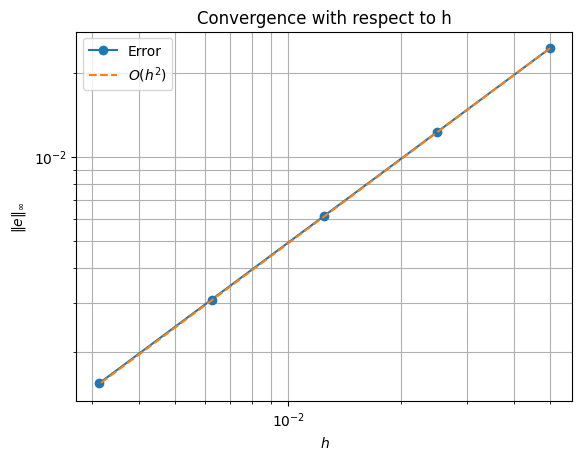

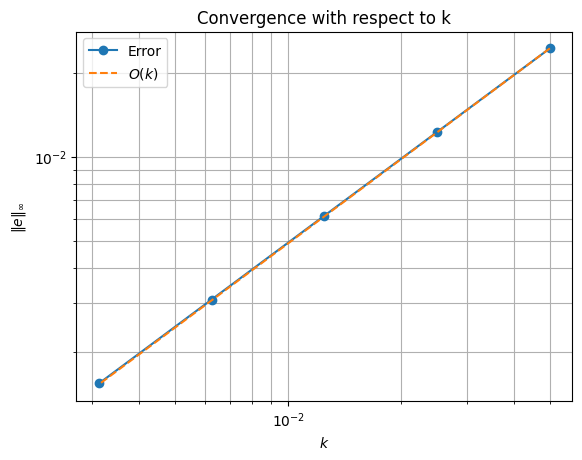

In [3]:
import numpy as np
import matplotlib.pyplot as plt

a = 0.5
epsilon = 0.1
T = 0.1

def exact_solution(x, t):
    y = x - a*t
    return np.sin(2*np.pi*y)

def solve_ftcs(N):
    h = 2 / N

    # Choosing k according to stability condition
    k = 0.5 * h / a
    M = int(np.ceil(T / k))
    k = T / M

    x = np.linspace(-1, 1, N+1)
    u = exact_solution(x, 0)

    nu = a*k/h

    for n in range(M):
        t_next = (n+1) * k
        u_new = u.copy()

        u_new[1:-1] = nu *u[:-2] + (1 - nu)*u[1:-1]

        # Dirichlet boundary values
        u_new[0] = exact_solution(-1, t_next)
        u_new[-1] = exact_solution(1, t_next)

        u = u_new

    error = np.max(np.abs(u - exact_solution(x, T)))
    return h, k, error

Ns = [40, 80, 160, 320, 640]

hs = []
ks = []
errors = []

for N in Ns:
    h, k, err = solve_ftcs(N)
    hs.append(h)
    ks.append(k)
    errors.append(err)

hs = np.array(hs)
ks = np.array(ks)
errors = np.array(errors)

# Rates with respect to h
rates_h = np.log(errors[:-1] / errors[1:]) / np.log(hs[:-1] / hs[1:])

# Rates with respect to k
rates_k = np.log(errors[:-1] / errors[1:]) / np.log(ks[:-1] / ks[1:])

# Plot error vs h
plt.figure()
plt.loglog(hs, errors, "o-", label="Error")
plt.loglog(hs, errors[0]*(hs/hs[0]), "--", label=r"$O(h^2)$")
plt.xlabel(r"$h$")
plt.ylabel(r"$\|e\|_\infty$")
plt.title("Convergence with respect to h")
plt.legend()
plt.grid(True, which="both")
plt.show()

# Plot error vs k
plt.figure()
plt.loglog(ks, errors, "o-", label="Error")
plt.loglog(ks, errors[0]*(ks/ks[0]), "--", label=r"$O(k)$")
plt.xlabel(r"$k$")
plt.ylabel(r"$\|e\|_\infty$")
plt.title("Convergence with respect to k")
plt.legend()
plt.grid(True, which="both")
plt.show()

### 3)

We set $\nu = \frac{ak}{h}$, from 1) we got
$$
g = \nu e^{-i\xi h} + (1-\nu)
$$

We found the amplitude error
$$
|g| = \sqrt{1-2\nu(1-\nu)(1-\cos{\xi h})}
$$


We can find the phase shift per step. 

$$
g = 1 - \frac{ak}{h}(-\cos(\xi h) + 1) - i\sin(\xi h)\frac{ak}{h}
$$
$$
\phi_{num} = \arg(g) = -\arctan\left(\frac{\nu\sin(\xi h)}{1 - \nu(1-\cos(\xi h)) }\right)
$$


The exact is given by
$$
\phi_{exact} =
$$

`Mangler lige at estimere det`

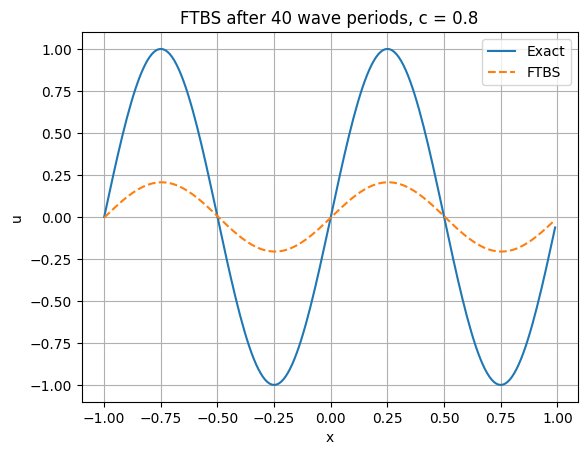

Numerical amplitude approx: 0.20611668247932394
Predicted amplitude: 0.206


In [5]:
import numpy as np
import matplotlib.pyplot as plt

a = 0.5
c = 0.8
ppw = 100

dx = 1 / ppw
dt = c * dx / a

T_period = 1 / a
T = 40 * T_period
M = int(round(T / dt))
dt = T / M
c = a * dt / dx

N = int(2 / dx)
x = np.linspace(-1, 1, N, endpoint=False)

u = np.sin(2*np.pi*x)

for n in range(M):
    u = (1 - c)*u + c*np.roll(u, 1)

u_exact = np.sin(2*np.pi*(x - a*T))

plt.plot(x, u_exact, label="Exact")
plt.plot(x, u, "--", label="FTBS")
plt.xlabel("x")
plt.ylabel("u")
plt.title("FTBS after 40 wave periods, c = 0.8")
plt.legend()
plt.grid()
plt.show()

print("Numerical amplitude approx:", np.max(np.abs(u)))
print("Predicted amplitude:", 0.206)

The FTBS scheme is strongly diffusive. For c=0.8 and 100 points per wavelength, the predicted amplitude after 40 periods is approximately 0.206, so the wave loses almost 80% of its amplitude. The predicted phase error is only about 0.316 grid cells, so the dispersion error is small compared with the diffusion error.